# Tropical Cyclone Loss Model - Refactored Pipeline

Here we validate the new class type architecture in a clean way. We import the NatCat modules and then get the storm track via the setup preprocessing pipeline and then calculate the loss. 

In [1]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('../src')

from hazards.tropical_cyclone import TropicalCycloneHazard
from vulnerability import WindVulnerability
from loss_model import LossCalculator

from preprocessing.tropical_cyclone import preprocess_B_deck

from preprocessing.tropical_cyclone import get_country_exposure_via_api, convert_to_loss_model_format



## Test for B deck

In [3]:
# Test with Michael (2018) - Atlantic storm #14
year = 2018
basin = 'al'           # Atlantic
storm_number = '14'    # Storm number (2 digits)

# Preprocessing pipeline 
df_track = preprocess_B_deck(year, basin, storm_number, verbose=1)

# Initialize models
hazard = TropicalCycloneHazard(df_track)
vulnerability = WindVulnerability()
loss = LossCalculator(hazard, vulnerability)

# Load portfolio via API and convert to loss model format
portfolio = get_country_exposure_via_api("USA", [24.5, 31.0, -87.6, -80.0])
portfolio = convert_to_loss_model_format(portfolio)

# Calculate losses
results = loss.calculate_portfolio_loss(portfolio)
print(f"\nTotal loss: ${loss.total_loss:,.0f}")
results.describe()

Year is 2018. Checking ARCHIVE source...


1it [00:00, 1521.88it/s]


Downloaded to /Users/wirths/Documents/Private/NatCat/src/preprocessing/tropical_cyclone/../../../data/raw/bal142018.dat.gz
Extracted to /Users/wirths/Documents/Private/NatCat/src/preprocessing/tropical_cyclone/../../../data/raw/bal142018.dat
Extracted track file: /Users/wirths/Documents/Private/NatCat/src/preprocessing/tropical_cyclone/../../../data/raw/bal142018.dat
Initializing CLIMADA Data Client...
Downloading/Loading USA exposure data (this may take a moment)...
Filtering for subregion: [24.5, 31.0, -87.6, -80.0]...

Total loss: $15,796,504,688


,location_id,latitude,longitude,tiv,intensity,damage_ratio,loss
count,8549.000000,8549.000000,8549.000000,8.549000e+03,8549.000000,8549.000000,8.549000e+03
mean,4275.000000,28.832239,-82.557548,5.773190e+08,20.902006,0.034459,1.847761e+06
std,2468.028059,1.674608,1.768458,2.011429e+09,25.130486,0.160574,5.324247e+07
min,1.000000,24.604167,-87.562500,0.000000e+00,7.378588,0.000000,0.000000e+00
25%,2138.000000,27.395833,-83.395833,2.774995e+04,11.822198,0.000000,0.000000e+00
50%,4275.000000,29.187500,-82.062500,9.769317e+05,12.930216,0.000000,0.000000e+00
75%,6412.000000,30.395833,-81.270833,5.690549e+07,16.893054,0.000000,0.000000e+00
max,8549.000000,30.979167,-80.062500,3.383002e+10,145.762161,0.994879,2.684730e+09


## Test timestamp specific calculations 

In [4]:
start = pd.to_datetime("2018-10-06 00:00:00")
desired = pd.date_range(start=start, end=df_track.time.max(), freq='6H')
timestamps = df_track.time[df_track.time.isin(desired)]

In [5]:
results_timeevo = loss.calculate_portfolio_loss_over_time(portfolio, desired)
results_timeevo.head()

,location_id,latitude,longitude,tiv,construction,timestamp,intensity,damage_ratio,loss
0,1,30.979167,-87.562500,1028755.45,Masonry,2018-10-06,0.0,0.0,0.0
1,2,30.979167,-87.520833,9999986.09,Frame,2018-10-06,0.0,0.0,0.0
2,3,30.979167,-87.479167,31000887.56,Masonry,2018-10-06,0.0,0.0,0.0
3,4,30.979167,-87.437500,9880534.74,Masonry,2018-10-06,0.0,0.0,0.0
4,5,30.979167,-87.395833,3495694.64,Masonry,2018-10-06,0.0,0.0,0.0


In [6]:
for timestamp in results_timeevo.timestamp.unique():
    results_timeevo_subset = results_timeevo[results_timeevo.timestamp == timestamp]
    #results_timeevo_subset.loss.sum()
    print(f"Total loss at {timestamp}: ${results_timeevo_subset.loss.sum():,.0f}")

Total loss at 2018-10-06 00:00:00: $0
Total loss at 2018-10-06 06:00:00: $0
Total loss at 2018-10-06 12:00:00: $0
Total loss at 2018-10-06 18:00:00: $0
Total loss at 2018-10-07 00:00:00: $0
Total loss at 2018-10-07 06:00:00: $0
Total loss at 2018-10-07 12:00:00: $0
Total loss at 2018-10-07 18:00:00: $0
Total loss at 2018-10-08 00:00:00: $0
Total loss at 2018-10-08 06:00:00: $0
Total loss at 2018-10-08 12:00:00: $0
Total loss at 2018-10-08 18:00:00: $0
Total loss at 2018-10-09 00:00:00: $0
Total loss at 2018-10-09 06:00:00: $0
Total loss at 2018-10-09 12:00:00: $0
Total loss at 2018-10-09 18:00:00: $0
Total loss at 2018-10-10 00:00:00: $0
Total loss at 2018-10-10 06:00:00: $0
Total loss at 2018-10-10 12:00:00: $0
Total loss at 2018-10-10 18:00:00: $14,216,386,736
Total loss at 2018-10-11 00:00:00: $15,796,504,688
Total loss at 2018-10-11 06:00:00: $15,796,504,688
Total loss at 2018-10-11 12:00:00: $15,796,504,688
Total loss at 2018-10-11 18:00:00: $15,796,504,688
Total loss at 2018-10-1

## Test visulaization 

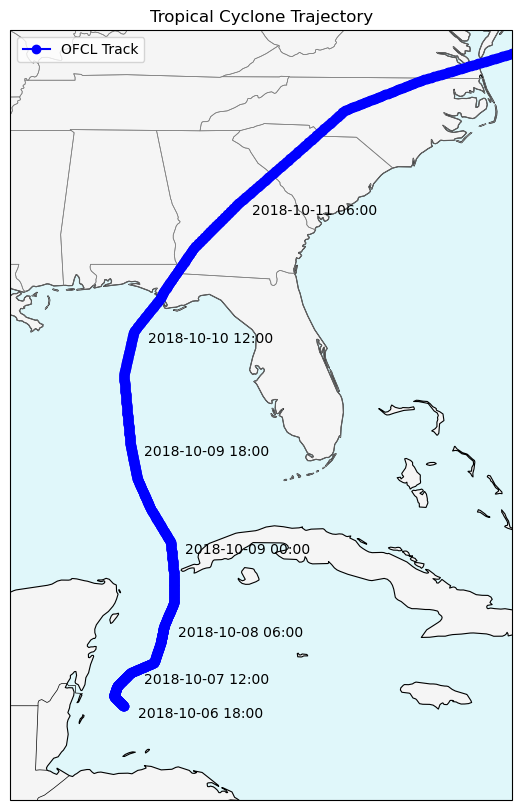

In [55]:
from visualization import plot_trajectory

fig = plot_trajectory(df_track,filestring='../plots/michael_trajectory.png')

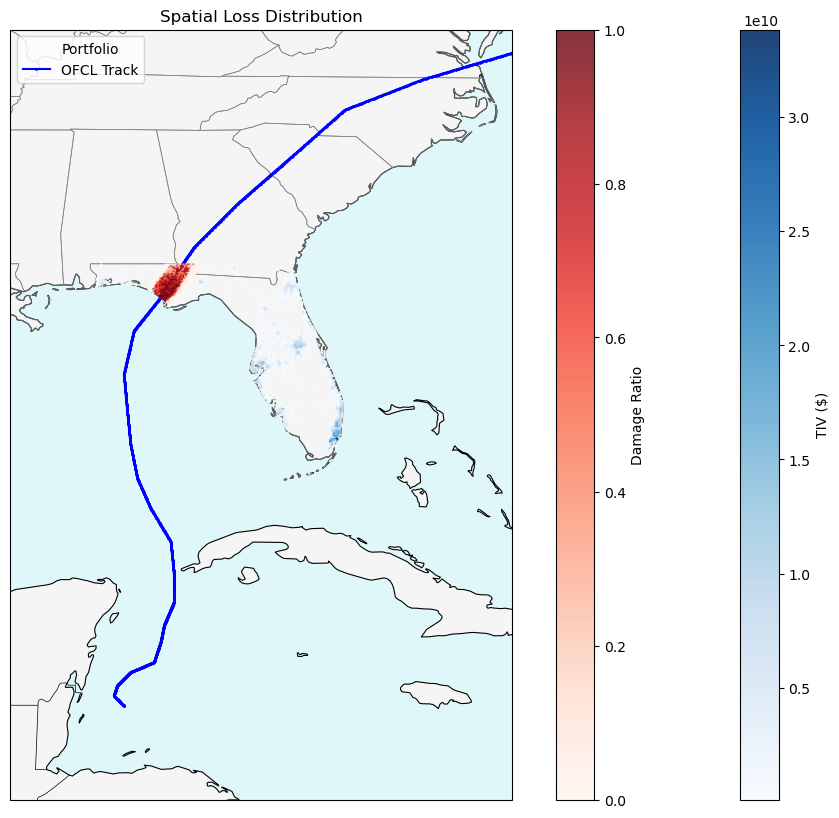

In [57]:
from visualization import spatial_loss
fig = spatial_loss(results_timeevo,portfolio=portfolio, damage_ratio=True, df_track=df_track, filestring='../plots/michael_damage_evolution.png')

## Temporal Animation of Loss Evolution

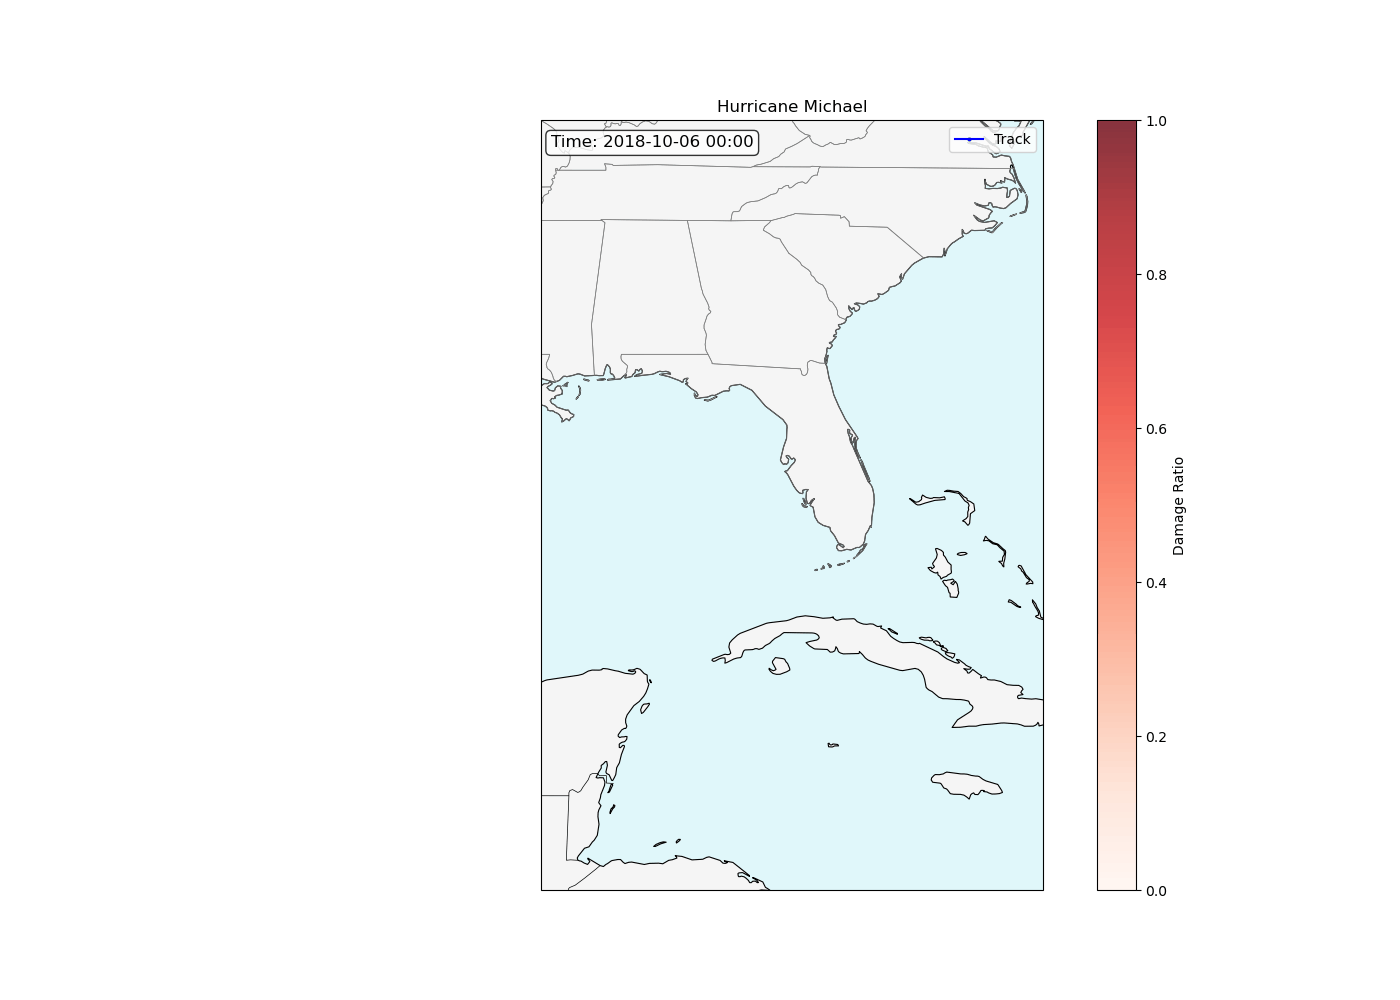

In [ ]:
# Temporal animation of Hurricane Michael damage evolution
from visualization.tropical_cyclone import animate_spatial_loss
import os

#os.makedirs('../animations', exist_ok=True)

# Use the time-evolution results
anim = animate_spatial_loss(
    df_loss=results_timeevo,
    df_track=df_track,
    damage_ratio=True,
    timestep_hours=6,
    filestring='../animations/michael_damage_evolution.gif',
    title='Hurricane Michael',
    fps=2
)

from IPython.display import Image
Image(filename='../animations/michael_damage_evolution.gif')
